# Modello per l'Identificazione della Lingua di Testi per un Museo </p> Caso d'Uso Aziendale: MuseumLangID

## Introduzione all'Azienda
MuseumLangID è un'iniziativa di un museo internazionale che ospita una vasta collezione di opere d'arte e manufatti. Le descrizioni degli oggetti sono spesso scritte in diverse lingue, e il personale del museo ha bisogno di uno strumento automatizzato per identificare rapidamente la lingua di questi testi.

## Problema
La gestione delle informazioni multilingue è una sfida significativa per il museo. Attualmente, la lingua di ogni descrizione deve essere identificata manualmente, il che richiede tempo e può portare a errori. Con l'espansione delle collezioni, il numero di testi da analizzare aumenta, rendendo necessario un approccio automatizzato e scalabile.

## Obiettivo del Progetto
L'obiettivo è sviluppare un modello di machine learning basato su tecniche di Natural Language Processing (NLP) per identificare la lingua di testi forniti dal museo. Questo modello dovrà:
1. Riconoscere automaticamente la lingua di un testo.
2. Supportare almeno 3 lingue principali.
3. Essere facile da integrare con il sistema esistente del museo.

## Benefici Attesi
- Automazione: Eliminare la necessità di identificazione manuale delle lingue.
- Efficienza: Processare rapidamente grandi volumi di testi.
- Accuratezza: Ridurre gli errori umani nell'identificazione delle lingue.

## Specifiche del Progetto
### Dataset
Il dataset è disponibile a questo link: https://raw.githubusercontent.com/Profession-AI/progetti-ml/refs/heads/main/Modello%20per%20l'identificazione%20della%20lingua%20dei%20testi%20di%20un%20museo/museo_descrizioni.csv. Contiene varie descrizioni in più lingue, con una colonna che rappresenta il codice della lingua, che è il target da prevedere.

### Tecnologie
- Linguaggio di programmazione: Python
- Librerie richieste:
    - scikit-learn
    - nltk
    - numpy
    - pandas

### Funzionalità Chiave
1. Preprocessing dei Dati:
    - Pulizia del testo (rimozione di caratteri speciali, normalizzazione).
    - Tokenizzazione e rappresentazione dei testi in un formato numerico (ad esempio, Bag of Words o TF-IDF).
2. Sviluppo del Modello:
    - Creazione di un modello di classificazione delle lingue basato su algoritmi di machine learning (ad esempio, Naive Bayes, Support Vector Machine o Random Forest).
    - Addestramento e validazione del modello sul dataset fornito.
3. Valutazione:
    - Utilizzare metriche come accuratezza, precisione, richiamo e F1-score per valutare le prestazioni del modello.

## Consegna
Dovrai consegnare un notebook che riporta la creazione del modello, i vari test per validare le sue performance e anche un commento a tali risultati.

## Import delle Librerie e hyperparametri

In [19]:
import pandas as pd
import spacy
import re
import matplotlib.pyplot as plt
import string
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, \
    confusion_matrix

In [20]:
RANDOM_SEED = 42
TEST_SPLIT_SIZE = 0.2

# TF-IDF Hyperparameters
TFIDF_MAX_FEATURES = 1000  # Limite numero massimo di feature
TFIDF_NGRAM_RANGE = (1, 2)  # Considera unigrammi e bigrammi
TFIDF_MIN_DF = 0.005  # Ignora parole che appaiono in meno del 20% dei documenti
TFIDF_MAX_DF = 0.8  # Ignora parole che appaiono in più dell'80% dei documenti (stop words)

## 1. Dataset

In [21]:
dataset = pd.read_csv(
    'https://raw.githubusercontent.com/Profession-AI/progetti-ml/refs/heads/main/Modello%20per%20l%27identificazione%20della%20lingua%20dei%20testi%20di%20un%20museo/museo_descrizioni.csv')

dataset_testo = dataset.iloc[:, 0]  # Testo
dataset_lingua = dataset.iloc[:, -1]  # Codice Lingua (target)

# 3 righe per ogni classe
dataset.groupby(dataset.columns[-1]).head(3)

,Testo,Codice Lingua
0,Statua in marmo di un imperatore romano del II...,it
1,Anfora greca con decorazioni a figure nere,it
2,Dipinto rinascimentale raffigurante la Madonna...,it
98,Marble statue of a Roman emperor from the 2nd ...,en
99,Greek amphora with black-figure decorations,en
100,Renaissance painting depicting the Madonna and...,en
196,Marmorstatue eines römischen Kaisers aus dem 2...,de
197,Griechische Amphore mit schwarzfigurigen Verzi...,de
198,Renaissance-Gemälde der Madonna mit Kind,de


### 1.1 Analisi Esplorativa del Dataset

In [39]:
print(f"  Righe    : {dataset.shape[0]}")
print(f"  Colonne  : {dataset.shape[1]}")
print(f"  Features  : {dataset.columns.tolist()}")
print(f"  Lingue presenti: {dataset_lingua.nunique()}")
for lang, count in dataset_lingua.value_counts().items():
    print(f"    - {lang}: {count} campioni ({(count / dataset.shape[0]) * 100:.2f}%)")

  Righe    : 294
  Colonne  : 2
  Features  : ['Testo', 'Codice Lingua']
  Lingue presenti: 3
    - it: 98 campioni (33.33%)
    - en: 98 campioni (33.33%)
    - de: 98 campioni (33.33%)


Il dataset é perfettamente bilanciato, con un numero uguale di campioni per ogni lingua.
Non sono presenti valori mancanti

## 2. Data Preprocessing

Funzione di pulizia e lemmatizzazione dei testi.

Visto che il task é una language identification, i numeri si possono rimuovere del tutto. Le stopwords invece provo a lasciarle, visto che possono essere molto indicative della lingua (ad esempio "the" per l'inglese, "le" per il francese)

In [23]:
!python -m spacy download it_core_news_sm
!python -m spacy download en_core_web_sm
!python -m spacy download de_core_news_sm

nlp_ita = spacy.load('it_core_news_sm')
nlp_en = spacy.load('en_core_web_sm')
nlp_de = spacy.load('de_core_news_sm')

# Mappa dei modelli spaCy per lingua (codici ISO 639-1)
nlp_map = {
    'it': nlp_ita,
    'en': nlp_en,
    'de': nlp_de,
}

def data_cleaner(dataset_testo, dataset_lingua):
    """
    Pulisce e lemmatizza i testi usando il modello spaCy corretto per ogni lingua.
    Per lingue non supportate esplicitamente, viene effettuata solo la pulizia base.

    :param dataset_testo: Serie di testi da pulire
    :param dataset_lingua: Serie di codici lingua corrispondenti ai testi
    :return: Lista di testi puliti e lemmatizzati
    """
    dataset_to_return = []
    for sentence, lang in zip(dataset_testo, dataset_lingua):
        sentence = sentence.lower()
        for c in string.punctuation:
            sentence = sentence.replace(c, " ")
        nlp = nlp_map.get(lang)
        if nlp is not None:
            document = nlp(sentence)
            sentence = ' '.join(token.lemma_ for token in document)
        sentence = re.sub(r'\d+', '', sentence)
        sentence = re.sub(r'\s+', ' ', sentence).strip()
        dataset_to_return.append(sentence)
    return dataset_to_return

  Using cached https://github.com/explosion/spacy-models/releases/download/it_core_news_sm-3.8.0/it_core_news_sm-3.8.0-py3-none-any.whl (13.0 MB)
✔ Download and installation successful
You can now load the package via spacy.load('it_core_news_sm')
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 12.8/12.8 MB 166.2 MB/s  0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
  Using cached https://github.com/explosion/spacy-models/releases/download/de_core_news_sm-3.8.0/de_core_news_sm-3.8.0-py3-none-any.whl (14.6 MB)
✔ Download and installation successful
You can now load the package via spacy.load('de_core_news_sm')


### 2.1 Pulizia del dataset

I testi vengono puliti e lemmatizzati usando il modello spaCy specifico per ogni lingua. Si rimuovono i numeri, ma si mantengono le stopwords, che possono essere molto indicative della lingua. Per lingue non supportate esplicitamente, viene effettuata solo la pulizia base (rimozione di punteggiatura e numeri). Successivamente, il dataset viene diviso in training set e test set, mantenendo la stessa distribuzione di lingue in entrambi i set (stratificazione). Infine, viene applicata la tecnica di feature extraction TF-IDF per convertire i testi in una rappresentazione numerica adatta all'addestramento dei modelli di machine learning.

In [40]:
# Pulizia del dataset
dataset_cleaned = data_cleaner(dataset_testo, dataset_lingua)

# Split del dataset
X_train, X_test, y_train, y_test = train_test_split(dataset_cleaned, dataset_lingua, test_size=TEST_SPLIT_SIZE,
                                                    random_state=RANDOM_SEED, stratify=dataset_lingua)

# Feature extraction con TF-IDF
vectorizer = TfidfVectorizer(max_features=TFIDF_MAX_FEATURES, ngram_range=TFIDF_NGRAM_RANGE, min_df=TFIDF_MIN_DF,
                             max_df=TFIDF_MAX_DF)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f"  Training set : {len(X_train)} campioni ({(1 - TEST_SPLIT_SIZE) * 100:.0f}%)")
print(f"  Test set     : {len(X_test)} campioni ({TEST_SPLIT_SIZE * 100:.0f}%)")
print()
print("  Distribuzione nel Training set:")
for lang, count in y_train.value_counts().items():
    print(f"    - {lang}: {count} campioni ({(count / len(y_train)) * 100:.2f}%)")
print()
print("  Distribuzione nel Test set:")
for lang, count in y_test.value_counts().items():
    print(f"    - {lang}: {count} campioni ({(count / len(y_test)) * 100:.2f}%)")
print()
print("  Forma della matrice TF-IDF del training set: ", X_train_tfidf.shape)
print("  Forma della matrice TF-IDF del test set: ", X_test_tfidf.shape)

  Training set : 235 campioni (80%)
  Test set     : 59 campioni (20%)

  Distribuzione nel Training set:
    - de: 79 campioni (33.62%)
    - en: 78 campioni (33.19%)
    - it: 78 campioni (33.19%)

  Distribuzione nel Test set:
    - it: 20 campioni (33.90%)
    - en: 20 campioni (33.90%)
    - de: 19 campioni (32.20%)

  Forma della matrice TF-IDF del training set:  (235, 304)
  Forma della matrice TF-IDF del test set:  (59, 304)


## 3. Sviluppo e Addestramento dei Modelli

### Modello 1: Naive Bayes Multinomiale

In [32]:
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

# Predizioni
y_pred_nb = nb_model.predict(X_test_tfidf)

# Accuratezza
accuracy_nb = accuracy_score(y_test, y_pred_nb)
print(f"Accuratezza: {accuracy_nb:.4f}")
print(f"\nReport di classificazione:\n{classification_report(y_test, y_pred_nb)}")

Accuratezza: 0.9831

Report di classificazione:
              precision    recall  f1-score   support

          de       1.00      1.00      1.00        19
          en       1.00      0.95      0.97        20
          it       0.95      1.00      0.98        20

    accuracy                           0.98        59
   macro avg       0.98      0.98      0.98        59
weighted avg       0.98      0.98      0.98        59



### Modello 2: Support Vector Machine (LinearSVC)

In [36]:
svm_model = LinearSVC(random_state=RANDOM_SEED, max_iter=1000)
svm_model.fit(X_train_tfidf, y_train)

# Predizioni
y_pred_svm = svm_model.predict(X_test_tfidf)

# Accuratezza
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"Accuratezza: {accuracy_svm:.4f}")
print(f"\nReport di classificazione:\n{classification_report(y_test, y_pred_svm)}")

Accuratezza: 0.9831

Report di classificazione:
              precision    recall  f1-score   support

          de       1.00      1.00      1.00        19
          en       1.00      0.95      0.97        20
          it       0.95      1.00      0.98        20

    accuracy                           0.98        59
   macro avg       0.98      0.98      0.98        59
weighted avg       0.98      0.98      0.98        59



### Modello 3: Multy Layer Perceptron (MLP Classifier)

In [38]:
mlp_model = MLPClassifier(
    hidden_layer_sizes=(256, 128),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=300,
    random_state=RANDOM_SEED,
    tol=0.005)

mlp_model.fit(X_train_tfidf, y_train)

# Predizioni
y_pred_mlp = mlp_model.predict(X_test_tfidf)

# Accuratezza
accuracy_mlp = accuracy_score(y_test, y_pred_mlp)
print(f"Accuratezza: {accuracy_mlp:.4f}")
print(f"\nReport di classificazione:\n{classification_report(y_test, y_pred_mlp)}")

Accuratezza: 0.9831

Report di classificazione:
              precision    recall  f1-score   support

          de       1.00      1.00      1.00        19
          en       1.00      0.95      0.97        20
          it       0.95      1.00      0.98        20

    accuracy                           0.98        59
   macro avg       0.98      0.98      0.98        59
weighted avg       0.98      0.98      0.98        59



## 4. Valutazione Comparativa dei Modelli

In [49]:
models_info = [
    ('Naive Bayes',     y_pred_nb),
    ('SVM (LinearSVC)', y_pred_svm),
    ('MLP Classifier',  y_pred_mlp),
]

results = []
for name, y_pred in models_info:
    results.append({
        'Modello':     name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision':  precision_score(y_test, y_pred, average='weighted'),
        'Recall':    recall_score(y_test, y_pred, average='weighted'),
        'F1-Score':    f1_score(y_test, y_pred, average='weighted'),
    })

comparison_df = pd.DataFrame(results)
print("=" * 80)
print("TABELLA COMPARATIVA DELLE METRICHE")
print("=" * 80)
print(comparison_df.to_string(index=False))
print("=" * 80)

TABELLA COMPARATIVA DELLE METRICHE
        Modello  Accuracy  Precision  Recall  F1-Score
    Naive Bayes   0.98305    0.98386 0.98305   0.98304
SVM (LinearSVC)   0.98305    0.98386 0.98305   0.98304
 MLP Classifier   0.98305    0.98386 0.98305   0.98304


### 4.1 Visualizzazione Grafica dei Risultati

Per ogni metrica (accuratezza, precisione, richiamo, F1-score) viene creato un grafico a barre che confronta le prestazioni dei tre modelli.

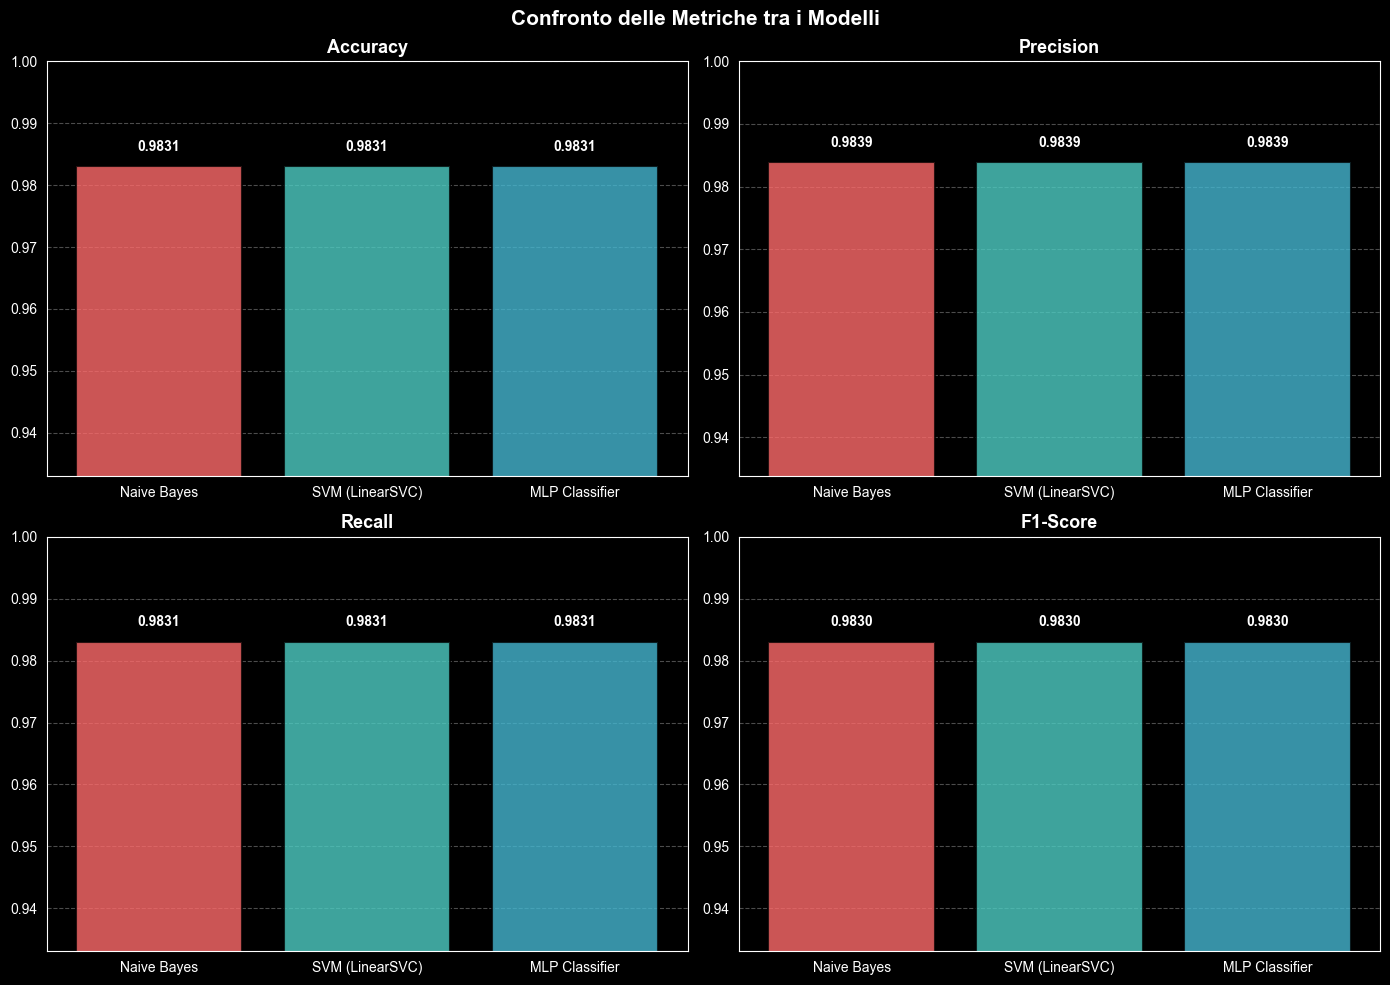

In [76]:
metriche = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

for idx, metrica in enumerate(metriche):
    ax = axes[idx // 2, idx % 2]
    values = comparison_df[metrica].tolist()
    bars = ax.bar(comparison_df['Modello'], values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
    ax.set_title(f'{metrica}', fontsize=13, fontweight='bold')
    ax.set_ylim([max(0.0, min(values) - 0.05), 1])
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.grid(axis='x', alpha=0)
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2., height + 0.002,
                f'{height:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.suptitle('Confronto delle Metriche tra i Modelli', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('images/modelli_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

Viene creata una matrice di confusione per ogni modello, visualizzata con una heatmap. Le matrici mostrano il numero di predizioni corrette e errate per ogni lingua, evidenziando eventuali confusione tra le classi.

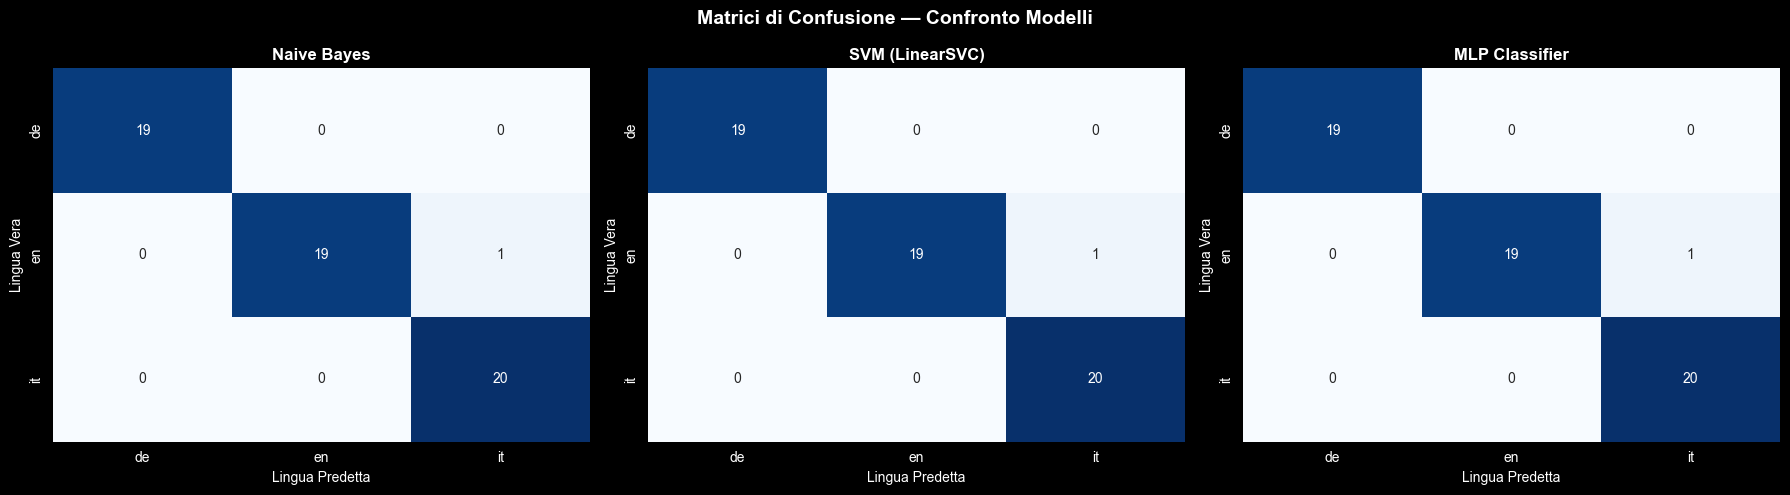

Matrici di confusione salvate come 'confusion_matrices.png'


In [77]:
lang_labels = sorted(dataset_lingua.unique())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, y_pred) in zip(axes, models_info):
    cm = confusion_matrix(y_test, y_pred, labels=lang_labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=lang_labels, yticklabels=lang_labels, cbar=False)
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Lingua Predetta', fontsize=10)
    ax.set_ylabel('Lingua Vera', fontsize=10)

plt.suptitle('Matrici di Confusione — Confronto Modelli', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/confusion_matrices.png', dpi=100, bbox_inches='tight')
plt.show()

In [79]:
best_model_idx  = comparison_df['F1-Score'].idxmax()
best_model_name = comparison_df.loc[best_model_idx, 'Modello']

model_map = {
    'Naive Bayes':     nb_model,
    'SVM (LinearSVC)': svm_model,
    'MLP Classifier':  mlp_model,
}
best_model = model_map[best_model_name]

print(f"\n{'='*60}")
print(f"  MODELLO MIGLIORE (per F1-Score): {best_model_name}")
print(f"{'='*60}")
for metric in metriche:
    print(f"  {metric:<14}: {comparison_df.loc[best_model_idx, metric]:.4f}")
print(f"{'='*60}")


  MODELLO MIGLIORE (per F1-Score): Naive Bayes
  Accuracy      : 0.9831
  Precision     : 0.9839
  Recall        : 0.9831
  F1-Score      : 0.9830


## 5. Test del Modello con Esempi Personalizzati

In [ ]:
def predict_text_language(model, text):
    """
    Predice la lingua di un testo dato un modello addestrato.

    Usa data_cleaner per il preprocessing: siccome la lingua del testo è
    sconosciuta a priori, viene passato il codice 'unknown', che non è presente
    in nlp_map, quindi verrà eseguita solo la pulizia base (lowercase,
    rimozione punteggiatura e numeri). Questo è il comportamento corretto
    in fase di inferenza.

    :param model: Modello sklearn già addestrato (es. nb_model, svm_model, ...)
    :param text: Testo inserito dall'utente (stringa)
    :return: Codice lingua predetto (es. 'it', 'en', 'de', ...)
    """
    cleaned = data_cleaner([text], ['unknown'])
    text_tfidf = vectorizer.transform(cleaned)
    return model.predict(text_tfidf)[0]

test_examples = [
    ("The Mona Lisa is one of the most famous paintings in the world",              "en"),
    ("La Gioconda è considerata una delle opere più importanti di Leonardo da Vinci","it"),
    ("Die Sixtinische Kapelle ist ein Meisterwerk der Renaissance",                 "de"),
    ("Le Louvre est le musée le plus visité au monde",                              "fr"),
    ("El Guernica es una obra de arte de Pablo Picasso",                            "es"),
    ("De Nachtwacht is een beroemd schilderij van Rembrandt van Rijn",              "nl"),
]

print(f"{'='*75}")
print(f"  TEST CON TESTI PERSONALIZZATI — Modello selezionato: {best_model_name}")
print(f"{'='*75}\n")

correct = 0
for i, (text, true_lang) in enumerate(test_examples, 1):
    predicted = predict_text_language(best_model, text)
    match = predicted == true_lang
    if match:
        correct += 1
    status = "✓  CORRETTO" if match else "✗  ERRATO  "
    print(f"  [{status}]  {text}")
    print(f"               Atteso: {true_lang}  |  Predetto: {predicted}\n")

print(f"  Risultato finale: {correct}/{len(test_examples)} corretti "
      f"({correct / len(test_examples) * 100:.0f}%)")
print(f"{'='*75}")